In [42]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [43]:
# 1.	Read the CSV. 
df = pd.read_csv('Delhi metro.csv')

In [44]:
# 2.	Print shape, column names, and dtypes.
df.shape

(285, 8)

In [45]:
list(df.columns)

['ID (Station ID)',
 'Station Names',
 'Dist. From First Station(km)',
 'Metro Line',
 'Opened(Year)',
 'Layout',
 'Latitude',
 'Longitude']

In [46]:
df.dtypes

ID (Station ID)                   int64
Station Names                       str
Dist. From First Station(km)    float64
Metro Line                          str
Opened(Year)                        str
Layout                              str
Latitude                        float64
Longitude                       float64
dtype: object

In [47]:
# 3.	Show the first 10 rows. Which columns are numeric, and which are text?
df.head(10)

,ID (Station ID),Station Names,Dist. From First Station(km),Metro Line,Opened(Year),Layout,Latitude,Longitude
0,1,Shaheed Sthal(First Station),0.0,Red line,08-03-2019,Elevated,28.670611,77.415582
1,2,Hindon River,1.0,Red line,08-03-2019,Elevated,28.878965,77.415483
2,3,Arthala,2.5,Red line,08-03-2019,Elevated,28.676999,77.391892
3,4,Mohan Nagar,3.2,Red line,08-03-2019,Elevated,28.606319,77.106082
4,5,Shyam park,4.5,Red line,08-03-2019,Elevated,28.698807,28.698807
5,6,Major Mohit Sharma,5.7,Red line,08-03-2019,Elevated,28.677611,77.358143
6,7,Raj Bagh,6.9,Red line,08-03-2019,Elevated,28.640860,77.209500
7,8,Shaheed Nagar,8.2,Red line,08-03-2019,Elevated,28.530780,77.212057
8,9,Dilshad Garden,9.4,Red line,04-06-2008,Elevated,28.675920,77.321420
9,10,Jhil Mil,10.3,Red line,04-06-2008,Elevated,28.675790,77.312390


In [48]:
# 4.	Check for missing values across all columns.
df.isna().sum()

ID (Station ID)                 0
Station Names                   0
Dist. From First Station(km)    0
Metro Line                      0
Opened(Year)                    0
Layout                          0
Latitude                        0
Longitude                       0
dtype: int64

In [49]:
# 5.	How many unique metro lines are there? List them with their station counts
len(df['Metro Line'].unique())

13

In [50]:
df['Metro Line'].value_counts()

Metro Line
Blue line            49
Pink line            38
Yellow line          37
Voilet line          34
Red line             29
Magenta line         25
Green line           21
Aqua line            21
Rapid Metro          11
Blue line branch      8
Orange line           6
Green line branch     3
Gray line             3
Name: count, dtype: int64

In [51]:
# 6. Opened (Year) is stored as text like 08-03-2019 — convert it to a proper datetime column.
df['Opened(Year)'] = pd.to_datetime(df['Opened(Year)'],dayfirst=True)

In [52]:
df.dtypes

ID (Station ID)                          int64
Station Names                              str
Dist. From First Station(km)           float64
Metro Line                                 str
Opened(Year)                    datetime64[us]
Layout                                     str
Latitude                               float64
Longitude                              float64
dtype: object

In [53]:
# 7. ID (Station ID) looks like it should be a unique key. Check df ['ID (Station ID)']. duplicated (). sum ()
df['ID (Station ID)'].duplicated().sum()

np.int64(236)

In [54]:
df['ID (Station ID)'].duplicated().value_counts()

ID (Station ID)
True     236
False     49
Name: count, dtype: int64

In [55]:
# 8. Are there any duplicate Station Names? Look them up — are they genuinely the same station or two different stations that happen to share a name?
df_dup = df[df['Station Names'].duplicated(keep= 'first')]
df_dup

,ID (Station ID),Station Names,Dist. From First Station(km),Metro Line,Opened(Year),Layout,Latitude,Longitude
115,1,Yamuna Bank,0.0,Blue line branch,2009-05-10,At-Grade,28.62331,77.26792
127,2,Ashok Park Main,1.4,Green line,2010-04-02,Elevated,28.67153,77.15527


In [56]:
df_dup = df[df['Station Names'].duplicated(keep= 'last')]
df_dup

,ID (Station ID),Station Names,Dist. From First Station(km),Metro Line,Opened(Year),Layout,Latitude,Longitude
99,34,Yamuna Bank,35.2,Blue line,2009-05-10,At-Grade,28.62331,77.26792
123,1,Ashok Park Main,0.0,Green line branch,2010-04-02,Elevated,28.67292,77.14420


In [57]:
# 9. Show all stations on the Blue line.
df9 = df[df['Metro Line'] == 'Blue line']
df9['Station Names']

66     Dwarka Sector 21(First station) [Conn: Orange]
67                                    Dwarka Sector 8
68                                    Dwarka Sector 9
69                                   Dwarka Sector 10
70                                   Dwarka Sector 11
71                                   Dwarka Sector 12
72                                   Dwarka Sector 13
73                                   Dwarka Sector 14
74                                Dwarka [Conn: Gray]
75                                         Dwarka Mor
76                                             Nawada
77                                   Uttam Nagar West
78                                   Uttam Nagar East
79                    Janak Puri West [Conn: Magenta]
80                                    Janak Puri East
81                                        Tilak Nagar
82                                      Subhash Nagar
83                                      Tagore Garden
84                        Ra

In [58]:
# 10. Which stations are Underground vs Elevated vs At-Grade? Count each.
df_under = df[df['Layout'] == 'Underground']
len(df_under)

68

In [59]:
df_elev = df[df['Layout'] == 'Elevated']
len(df_elev)

214

In [60]:
df_grad = df[df['Layout'] == 'At-Grade']
len(df_grad)

3

In [61]:
# 11. Find every station more than 40 km from its line's first station.
df11 = df[df['Dist. From First Station(km)']>40]
df11

,ID (Station ID),Station Names,Dist. From First Station(km),Metro Line,Opened(Year),Layout,Latitude,Longitude
61,33,Guru Dronacharya,40.9,Yellow line,2010-06-21,Elevated,28.482030,77.102320
62,34,Sikandarpur [Conn: Rapid],41.9,Yellow line,2010-06-21,Elevated,28.481820,77.092350
63,35,MG Road,43.1,Yellow line,2010-06-21,Elevated,28.479570,77.080060
64,36,IFFCO Chowk,44.2,Yellow line,2010-06-21,Elevated,28.472090,77.071750
65,37,Huda City Centre,45.7,Yellow line,2010-06-21,Elevated,28.459270,77.072680
103,38,New Ashok Nagar,40.4,Blue line,2009-11-12,Elevated,28.589160,77.302040
104,39,Noida Sector 15,41.4,Blue line,2009-11-12,Elevated,28.585120,77.311390
105,40,Noida Sector 16,42.5,Blue line,2009-11-12,Elevated,28.578190,77.317570
106,41,Noida Sector 18,43.6,Blue line,2009-11-12,Elevated,28.570810,77.326120
107,42,Botanical Garden [Conn: Magenta],44.7,Blue line,2009-11-12,Elevated,28.564090,77.334200


In [62]:
df11.value_counts(df['Metro Line'])

Metro Line
Blue line      12
Pink line      12
Yellow line     5
Voilet line     3
Name: count, dtype: int64

In [63]:
# 12. Sort stations by Opened (Year) — which was the very first station to open, and which is the most recent?
df12 = df.sort_values(by='Opened(Year)')
df12.head(1)

,ID (Station ID),Station Names,Dist. From First Station(km),Metro Line,Opened(Year),Layout,Latitude,Longitude
11,12,Shahdara,12.5,Red line,2002-12-24,Elevated,28.67345,77.28962


In [64]:
# which is the most recent
df12 = df.sort_values(by='Opened(Year)',ascending=False)
df12.head(1)

,ID (Station ID),Station Names,Dist. From First Station(km),Metro Line,Opened(Year),Layout,Latitude,Longitude
277,2,Nangli,1.5,Gray line,2019-10-04,Elevated,28.6173,77.010437


In [65]:
# 13. Average distance from first station, grouped by Metro Line — which line is longest end-to-end?
df.groupby('Metro Line')['Dist. From First Station(km)'].mean().sort_values(ascending=False)

Metro Line
Pink line            28.773684
Blue line            26.144898
Yellow line          21.462162
Voilet line          20.617647
Magenta line         17.656000
Red line             16.558621
Aqua line            13.352381
Green line           11.380952
Orange line          10.566667
Rapid Metro           5.709091
Blue line branch      4.000000
Gray line             1.800000
Green line branch     1.066667
Name: Dist. From First Station(km), dtype: float64

In [66]:
# 14. Count of stations per Metro Line, sorted descending.
df.groupby('Metro Line')['Station Names'].count().sort_values(ascending=False)

Metro Line
Blue line            49
Pink line            38
Yellow line          37
Voilet line          34
Red line             29
Magenta line         25
Aqua line            21
Green line           21
Rapid Metro          11
Blue line branch      8
Orange line           6
Gray line             3
Green line branch     3
Name: Station Names, dtype: int64

In [67]:
# 15. Group by Layout and Metro Line together — which lines are mostly underground vs mostly elevated?
pd.crosstab(df['Metro Line'],df['Layout'])

Layout,At-Grade,Elevated,Underground
Metro Line,,,
Aqua line,0,21,0
Blue line,1,44,4
Blue line branch,1,7,0
Gray line,0,2,1
Green line,0,21,0
Green line branch,1,2,0
Magenta line,0,10,15
Orange line,0,1,5
Pink line,0,26,12


In [68]:
# 16. How many stations opened each year? Which year had the most openings?
df['Year'] = df['Opened(Year)'].dt.year
df.groupby('Year')['Station Names'].count().sort_values(ascending=False)

Year
2018    64
2010    54
2019    37
2005    28
2017    18
2009    17
2011    13
2015    13
2004    11
2006     9
2002     6
2013     5
2003     4
2008     3
2014     3
Name: Station Names, dtype: int64

In [69]:
# 17. Extract just the year from Opened (Year) into a new integer column.
df['Year'] = df['Opened(Year)'].dt.year
df

,ID (Station ID),Station Names,Dist. From First Station(km),Metro Line,Opened(Year),Layout,Latitude,Longitude,Year
0,1,Shaheed Sthal(First Station),0.0,Red line,2019-03-08,Elevated,28.670611,77.415582,2019
1,2,Hindon River,1.0,Red line,2019-03-08,Elevated,28.878965,77.415483,2019
2,3,Arthala,2.5,Red line,2019-03-08,Elevated,28.676999,77.391892,2019
3,4,Mohan Nagar,3.2,Red line,2019-03-08,Elevated,28.606319,77.106082,2019
4,5,Shyam park,4.5,Red line,2019-03-08,Elevated,28.698807,28.698807,2019
...,...,...,...,...,...,...,...,...,...
280,2,Shivaji Stadium,1.9,Orange line,2011-02-23,Underground,28.629010,77.211900,2011
281,3,Dhaula Kuan [Conn: Pink],8.3,Orange line,2011-08-15,Elevated,28.591780,77.161550,2011
282,4,Delhi Aerocity,14.5,Orange line,2011-08-15,Underground,28.548810,77.120920,2011
283,5,IGI Airport,17.9,Orange line,2011-02-23,Underground,28.556930,77.086690,2011


In [70]:
# 18. Bar plot of station count per Metro Line
df18 = df['Metro Line'].value_counts().reset_index()
df18

,Metro Line,count
0,Blue line,49
1,Pink line,38
2,Yellow line,37
3,Voilet line,34
4,Red line,29
5,Magenta line,25
6,Green line,21
7,Aqua line,21
8,Rapid Metro,11
9,Blue line branch,8


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, 'Blue line'),
  Text(1, 0, 'Pink line'),
  Text(2, 0, 'Yellow line'),
  Text(3, 0, 'Voilet line'),
  Text(4, 0, 'Red line'),
  Text(5, 0, 'Magenta line'),
  Text(6, 0, 'Green line'),
  Text(7, 0, 'Aqua line'),
  Text(8, 0, 'Rapid Metro'),
  Text(9, 0, 'Blue line branch'),
  Text(10, 0, 'Orange line'),
  Text(11, 0, 'Green line branch'),
  Text(12, 0, 'Gray line')])

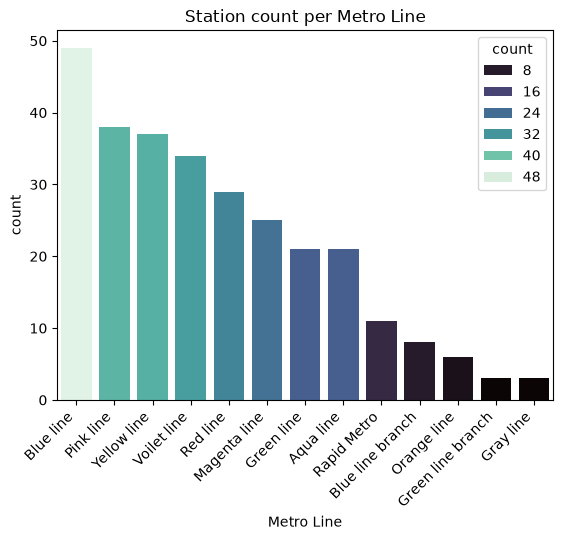

In [71]:
# plot
plt.Figure(figsize=(7,5))
sns.barplot(data=df18,x='Metro Line',y='count',hue='count',palette=sns.color_palette("mako", as_cmap=True))
plt.title('Station count per Metro Line')
plt.xticks(rotation = 45,ha = 'right')

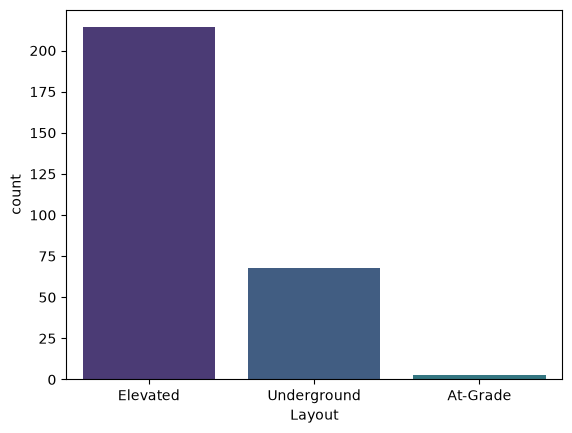

In [72]:
# 19. Countplot of Layout (Elevated/Underground/At-Grade).
plt.Figure(figsize=(7,5))
cp = sns.countplot(data=df,x='Layout',hue='Layout',order=df['Layout'].value_counts().index,palette=sns.color_palette('viridis'))

<Axes: xlabel='Dist. From First Station(km)', ylabel='Count'>

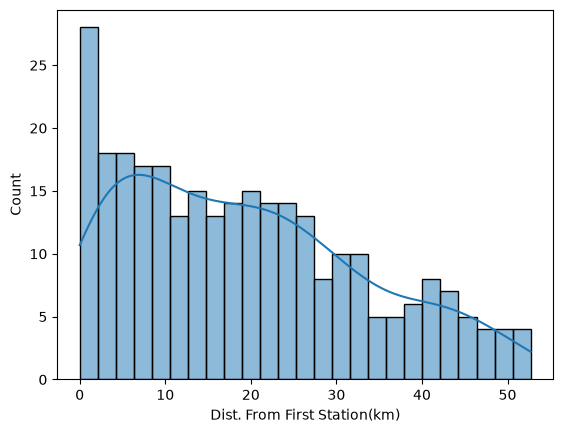

In [73]:
# 20. Histogram of Dist. From First Station(km) — what shape is the distribution?
sns.histplot(data=df,x='Dist. From First Station(km)',bins=25,kde=True)